In [7]:
# Run this cell only if you need to install missing packages.
# Note: On some systems (cvxpy, stable-baselines3) OS-level dependencies are required.
# In Jupyter run: !pip install -r requirements.txt OR run the lines below selectively.

!pip install numpy pandas scikit-learn matplotlib seaborn xgboost lightgbm ngboost pyyaml joblib scipy statsmodels torch tqdm
# Optional / advanced:
# !pip install cvxpy stable-baselines3 gym pandas_market_calendars


In [8]:
pip install ngboost

Note: you may need to restart the kernel to use updated packages.


In [9]:
# Core imports and experiment configuration
import os, yaml, random, math
import numpy as np, pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Metrics & models imports (some may be missing until installed)
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

# Config (modify as needed)
cfg = {
    "seed": 42,
    "start_date": "2020-01-01",
    "years": 2,
    "freq": "H",
    "forecast_horizon_hours": 24,
    "dataset": {"noise_std": 0.05, "anomaly_rate": 0.001},
    "models": {
        "rf_n_estimators": 200,
        "xgb_n_estimators": 200,
        "lgb_n_estimators": 200,
        "ngb_n_estimators": 500,
        "pytorch": {"seq_len":168, "epochs":10, "batch_size":64, "lr":1e-3}
    },
    "storage": {"battery_capacity":10000.0, "initial_soc_fraction":0.5},
    "training": {"test_days":180, "n_bootstrap_seeds":30},
    "artifacts": {"out_dir":"./artifacts", "figures_dir":"./artifacts/figures", "data_dir":"./artifacts/data", "metrics_file":"./artifacts/metrics.csv"}
}

# Create artifact dirs
os.makedirs(cfg["artifacts"]["out_dir"], exist_ok=True)
os.makedirs(cfg["artifacts"]["figures_dir"], exist_ok=True)
os.makedirs(cfg["artifacts"]["data_dir"], exist_ok=True)

# Seed
random.seed(cfg["seed"])
np.random.seed(cfg["seed"])
try:
    import torch
    torch.manual_seed(cfg["seed"])
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(cfg["seed"])
except Exception:
    pass

print("Config loaded. Artifacts ->", cfg["artifacts"]["out_dir"])


Config loaded. Artifacts -> ./artifacts


In [10]:
# Utilities: metrics, plotting helpers, paired tests
from scipy.stats import wilcoxon

def smape(true, pred):
    true, pred = np.array(true), np.array(pred)[:len(true)]
    denom = (np.abs(true) + np.abs(pred)) + 1e-6
    return 100.0 * np.mean(2.0*np.abs(pred - true) / denom)

def compute_metrics(true, pred):
    true, pred = np.array(true), np.array(pred)[:len(true)]
    mae = mean_absolute_error(true, pred)
    rmse = sqrt(mean_squared_error(true, pred))
    sm = smape(true, pred)
    return {"MAE": mae, "RMSE": rmse, "SMAPE": sm}

def paired_wilcoxon(true, pred_a, pred_b):
    try:
        stat, p = wilcoxon(np.abs(true - pred_a)[:len(true)], np.abs(true - pred_b)[:len(true)])
    except Exception:
        stat, p = None, None
    return stat, p

def save_df_csv(df, path):
    df.to_csv(path, index=False)

def plot_timeseries(index, actual, preds_dict, title, path, figsize=(12,4)):
    plt.figure(figsize=figsize)
    plt.plot(index, actual, label='Actual', linewidth=1.5)
    for name, series in preds_dict.items():
        plt.plot(index, series, label=name, alpha=0.9)
    plt.title(title); plt.legend(); plt.tight_layout()
    plt.savefig(path); plt.close()

def plot_error_box(errors_dict, title, path):
    plt.figure(figsize=(8,4))
    plt.boxplot(list(errors_dict.values()), labels=list(errors_dict.keys()))
    plt.title(title)
    plt.ylabel('Absolute error')
    plt.tight_layout(); plt.savefig(path); plt.close()


In [11]:
# Model wrappers. If a package is missing, pip-install cell (Cell 1) then re-run.
try:
    from sklearn.ensemble import RandomForestRegressor
    import xgboost as xgb
    import lightgbm as lgb
    from ngboost import NGBoost
    from ngboost.distns import Normal
    from ngboost.scores import MLE
except Exception as e:
    print("Model imports issue:", e)
    print("If missing, run Cell 1 to install packages then re-run this cell.")
    raise

def train_rf(X,y, n_estimators=200, seed=42):
    model = RandomForestRegressor(n_estimators=n_estimators, random_state=seed, n_jobs=-1)
    model.fit(X,y)
    return model

def train_xgb(X,y, n_estimators=200, seed=42):
    model = xgb.XGBRegressor(n_estimators=n_estimators, random_state=seed, verbosity=0)
    model.fit(X,y)
    return model

def train_lgb(X,y, n_estimators=200, seed=42):
    model = lgb.LGBMRegressor(n_estimators=n_estimators, random_state=seed)
    model.fit(X,y)
    return model

def train_ngboost(X,y, n_estimators=500, seed=42):
    ng = NGBoost(Dist=Normal, Score=MLE(), n_estimators=n_estimators, random_state=seed)
    ng.fit(X,y)
    return ng


In [12]:
# PyTorch LSTM for univariate sequence forecasting
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, series, seq_len):
        self.series = np.array(series, dtype=np.float32)
        self.seq_len = seq_len
    def __len__(self):
        return len(self.series) - self.seq_len
    def __getitem__(self, idx):
        x = self.series[idx:idx+self.seq_len]
        y = self.series[idx+self.seq_len]
        return torch.tensor(x).unsqueeze(-1), torch.tensor(y)

class LSTMModel(nn.Module):
    def __init__(self, seq_len, hidden=64, nlayers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=nlayers, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden,32), nn.ReLU(), nn.Linear(32,1))
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.head(out).squeeze(-1)

def train_lstm_univariate(series, seq_len=168, epochs=10, batch_size=64, lr=1e-3, device=None):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    ds = SeqDataset(series, seq_len)
    split = int(len(ds)*0.8)
    train_idx = list(range(split))
    val_idx = list(range(split, len(ds)))
    train_loader = DataLoader(torch.utils.data.Subset(ds, train_idx), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(torch.utils.data.Subset(ds, val_idx), batch_size=batch_size, shuffle=False)
    model = LSTMModel(seq_len).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for ep in range(epochs):
        model.train()
        for xb,yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward(); opt.step()
        # optional: compute val loss each epoch (omitted for brevity)
    return model, device

def infer_lstm(model, series, seq_len, device='cpu'):
    model.to(device); model.eval()
    preds = []
    with torch.no_grad():
        for i in range(len(series)-seq_len):
            seq = torch.tensor(series[i:i+seq_len], dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
            p = model(seq).cpu().numpy().flatten()[0]
            preds.append(p)
    return np.array(preds)


In [13]:
# Storage helpers: simple rule-based and RF-informed SOC simulation, MPC skeleton via cvxpy if available
def simulate_rule_soc(pv_series, demand_series, capacity, soc0=0.5):
    soc = capacity * soc0
    soc_trace = []
    for pv, d in zip(pv_series, demand_series):
        delta = pv - d*0.3
        soc = np.clip(soc + 0.1*delta, 0, capacity)
        soc_trace.append(soc)
    return np.array(soc_trace)

def simulate_rf_soc(pv_series, demand_series, capacity, rf_pred, soc0=0.5):
    soc = capacity * soc0
    soc_trace = []
    for pv, d, pred in zip(pv_series, demand_series, rf_pred):
        delta = pred - d*0.3
        soc = np.clip(soc + 0.12*delta - 0.01*np.sign(delta)*min(abs(delta),50), 0, capacity)
        soc_trace.append(soc)
    return np.array(soc_trace)

# MPC skeleton if cvxpy is installed
try:
    import cvxpy as cp
    def solve_mpc_simple(pv_forecast, demand_forecast, capacity, soc0, horizon=24, eff=0.9):
        T = horizon
        soc = cp.Variable(T+1)
        charge = cp.Variable(T)
        constraints = [soc[0] == soc0*capacity, soc >= 0, soc <= capacity]
        for t in range(T):
            constraints += [soc[t+1] == soc[t] + eff*charge[t], cp.abs(charge[t]) <= capacity*0.2]
        unmet = []
        for t in range(T):
            discharge = cp.pos(-charge[t]) * eff
            unmet.append(cp.pos(demand_forecast[t] - pv_forecast[t] - discharge))
        obj = cp.Minimize(cp.sum_squares(cp.hstack(unmet)))
        prob = cp.Problem(obj, constraints)
        prob.solve(solver=cp.OSQP, verbose=False)
        return soc.value, charge.value
except Exception:
    def solve_mpc_simple(*args, **kwargs):
        raise RuntimeError("cvxpy is not installed. Install or skip MPC.")


In [14]:
# Fixed synthetic generator cell (replace your previous cell 7 with this)
import numpy as np
import pandas as pd
import os

def generate_synthetic_fixed(cfg):
    # use lowercase 'h' to avoid FutureWarning
    start = pd.to_datetime(cfg["start_date"])
    periods = int(24 * 365 * cfg["years"])
    idx = pd.date_range(start, periods=periods, freq='h')   # <-- lowercase 'h'
    t = np.arange(periods)

    def seasonal_component(t_arr, period_hours, amplitude=1.0, phase=0.0):
        return amplitude * np.sin(2 * np.pi * (t_arr/period_hours) + phase)

    day_hours = 24
    year_hours = 24*365

    # --- PV (clear-sky + clouds + temp effect) ---
    solar_clear = np.clip(
        seasonal_component(t % day_hours, day_hours, amplitude=1.0, phase=-np.pi/2) *
        (1 + 0.3*seasonal_component(t, year_hours, amplitude=0.5)),
        0, None
    )
    cloud_low_freq = np.convolve(np.random.randn(periods), np.ones(24)/24, mode='same') * 0.2
    clouds = np.exp(-np.abs(cloud_low_freq))
    solar_irradiance = solar_clear * clouds
    temp_daily = 15 + 10*seasonal_component(t, year_hours, amplitude=1.0) + 5*seasonal_component(t, day_hours, 0.2)
    pv_power = np.clip(solar_irradiance * (1 - 0.005*(temp_daily-25)), 0, None) * 1000.0

    # --- Wind (seasonal + gusts + power curve) ---
    wind_base = 6 + 2*seasonal_component(t, year_hours, amplitude=1.0) + 0.5*seasonal_component(t, day_hours, 0.5)
    gusts = np.random.randn(periods) * 1.5
    wind_speed = np.clip(wind_base + gusts + 0.5*np.random.randn(periods), 0, None)

    def wind_power_from_speed(v):
        rated = 12.0; cut_in = 3.5; cut_out = 25.0
        if v < cut_in or v > cut_out:
            return 0.0
        swept = v**3
        return min(swept/(rated**3) * 3000.0, 3000.0)

    wind_power = np.array([wind_power_from_speed(v) for v in wind_speed])

    # --- Demand (seasonal + weekday + temp effect + noise) ---
    base = 2000 + 300*seasonal_component(t, year_hours, amplitude=0.6)
    weekday = np.array([1.0 if ts.weekday() < 5 else 0.85 for ts in idx])
    temp_effect = 1 + 0.01*(25 - temp_daily)
    demand = np.clip(base * weekday * temp_effect + 100*np.random.randn(periods), 500, None)

    # Compose dataframe
    df = pd.DataFrame({
        "timestamp": idx,
        "pv_power": pv_power,
        "wind_power": wind_power,
        "demand": demand,
        "temp": temp_daily,
        "wind_speed": wind_speed,
        "solar_irradiance": solar_irradiance
    }).set_index("timestamp")

    # --- anomalies: perturb some pv_power entries ---
    n_anom = max(1, int(cfg["dataset"].get("anomaly_rate", 0.001) * len(df)))
    anom_idx = np.random.choice(len(df), n_anom, replace=False)
    # apply multiplicative anomaly factors safely
    factors = (0.2 + 1.5 * np.random.rand(n_anom))
    df.iloc[anom_idx, df.columns.get_loc("pv_power")] = df.iloc[anom_idx, df.columns.get_loc("pv_power")] * factors

    # --- Add noise: construct noise array with correct broadcasting ---
    # compute per-column std (as 1D numpy array)
    col_std = df.std(axis=0).values  # length = n_columns
    noise_matrix = np.random.randn(*df.shape)  # shape = (periods, n_columns)
    # scale noise per column and by configured noise_std
    noise = cfg["dataset"].get("noise_std", 0.05) * noise_matrix * col_std[np.newaxis, :]
    # build DataFrame from noise with same columns and index for safe addition
    noise_df = pd.DataFrame(noise, index=df.index, columns=df.columns)
    df_noisy = df + noise_df

    # final sanity checks
    assert df_noisy.shape[0] == periods, f"unexpected rows: {df_noisy.shape[0]} vs {periods}"
    assert df_noisy.shape[1] == df.shape[1], "column mismatch after noise"

    return df_noisy

# Run it now (using cfg from your notebook)
df = generate_synthetic_fixed(cfg)
out_dir = cfg["artifacts"]["data_dir"]
os.makedirs(out_dir, exist_ok=True)
csv_path = os.path.join(out_dir, "synthetic_2yr_hourly_fixed.csv")
df.to_csv(csv_path)
print("Generated df shape:", df.shape)
print("Saved to:", csv_path)
df.head()


Generated df shape: (17520, 6)
Saved to: ./artifacts/data\synthetic_2yr_hourly_fixed.csv


,pv_power,wind_power,demand,temp,wind_speed,solar_irradiance
timestamp,,,,,,
2020-01-01 00:00:00,-26.205812,427.023877,2246.509966,15.143348,6.110995,0.022164
2020-01-01 01:00:00,-0.765800,709.932484,2194.087935,15.554580,7.645188,-0.009906
2020-01-01 02:00:00,6.980476,154.922990,2072.138726,15.726206,4.433585,-0.006879
2020-01-01 03:00:00,-0.998847,919.396625,2310.635202,15.816015,8.024066,-0.042426
2020-01-01 04:00:00,-9.182654,-6.047317,2118.958900,15.328578,2.863540,-0.012036


In [15]:
# CELL 8 — Feature engineering (lags, time features) and robust train/test split
import numpy as np

horizon = cfg["forecast_horizon_hours"]
df2 = df.copy()  # from the fixed generator cell

# create targets and lag features (same as before, but fully defensive)
df2["pv_target"] = df2["pv_power"].shift(-horizon)
df2["wind_target"] = df2["wind_power"].shift(-horizon)

for lag in [1,2,3,24,48,168]:
    df2[f"pv_lag_{lag}"] = df2["pv_power"].shift(lag)
    df2[f"wind_lag_{lag}"] = df2["wind_power"].shift(lag)

df2["hour"] = df2.index.hour
df2["dayofweek"] = df2.index.dayofweek

# Drop rows with any NaN created by shifting
df2 = df2.dropna().astype(float)

# Train/test split (last N days -> test)
test_periods = cfg["training"]["test_days"] * 24
if len(df2) <= test_periods + 500:
    # defensive: ensure there is adequate training data
    raise RuntimeError(f"Not enough data after feature engineering. rows={len(df2)}, test_periods={test_periods}")

train = df2.iloc[:-test_periods].copy()
test = df2.iloc[-test_periods:].copy()

features = [c for c in df2.columns if c not in ["pv_target", "wind_target"]]

X_train = train[features].values
X_test = test[features].values
y_train_pv = train["pv_target"].values
y_test_pv = test["pv_target"].values
y_train_wind = train["wind_target"].values
y_test_wind = test["wind_target"].values

print("Feature engineering done.")
print("Train / Test shapes:", X_train.shape, X_test.shape)


Feature engineering done.
Train / Test shapes: (13008, 20) (4320, 20)


In [16]:
# CELL 9_fixed — Defensive model imports + DataFrame-aware wrappers
try:
    from sklearn.ensemble import RandomForestRegressor
    import xgboost as xgb
    import lightgbm as lgb
    from ngboost import NGBoost
    # avoid importing Score/Dist combinations to prevent version-dependent issues
except Exception as e:
    print("Model imports failed:", e)
    raise

def train_rf_df(X_df, y, n_estimators=200, seed=42):
    """Train RF using a DataFrame X_df (keeps feature names)."""
    m = RandomForestRegressor(n_estimators=n_estimators, random_state=seed, n_jobs=-1)
    m.fit(X_df, y)
    return m

def train_xgb_df(X_df, y, n_estimators=200, seed=42):
    m = xgb.XGBRegressor(n_estimators=n_estimators, random_state=seed, verbosity=0)
    # XGBoost accepts DataFrame
    m.fit(X_df, y)
    return m

def train_lgb_df(X_df, y, n_estimators=200, seed=42):
    m = lgb.LGBMRegressor(n_estimators=n_estimators, random_state=seed)
    m.fit(X_df, y)
    return m

def train_ngboost_df(X_df, y, n_estimators=500, seed=42):
    """
    Use NGBoost with default Score/Dist to avoid version mismatch.
    If you want Normal+MLE specifically, update only after confirming ngboost version supports it.
    """
    ng = NGBoost(n_estimators=n_estimators, random_state=seed)
    ng.fit(X_df, y)
    return ng

print("Model wrappers (DataFrame-aware) ready.")


Model wrappers (DataFrame-aware) ready.


In [17]:
# CELL 10_fixed — Train models using DataFrames (avoids feature-name warnings) and get preds
import pandas as pd
from sklearn.metrics import mean_absolute_error

# Build DataFrame inputs for train / test using 'features' list (constructed earlier)
X_train_df = pd.DataFrame(X_train, columns=features, index=train.index)
X_test_df  = pd.DataFrame(X_test,  columns=features, index=test.index)

# Persistence baseline aligned robustly (shift by horizon on the original df)
persistence_pv = df.loc[test.index, "pv_power"].shift(cfg["forecast_horizon_hours"]).fillna(method="bfill").values
persistence_wind = df.loc[test.index, "wind_power"].shift(cfg["forecast_horizon_hours"]).fillna(method="bfill").values

# Train RandomForest on DataFrame
rf_model = train_rf_df(X_train_df, y_train_pv, n_estimators=cfg["models"]["rf_n_estimators"], seed=cfg["seed"])
rf_pred_pv = rf_model.predict(X_test_df)  # DataFrame passed — no warnings

# Train XGBoost (DataFrame)
xgb_model = train_xgb_df(X_train_df, y_train_pv, n_estimators=cfg["models"]["xgb_n_estimators"], seed=cfg["seed"])
xgb_pred_pv = xgb_model.predict(X_test_df)

# Train LightGBM (DataFrame)
lgb_model = train_lgb_df(X_train_df, y_train_pv, n_estimators=cfg["models"]["lgb_n_estimators"], seed=cfg["seed"])
lgb_pred_pv = lgb_model.predict(X_test_df)  # no feature-name warning now

# Train NGBoost (DataFrame) — robust default constructor
ngb_model = train_ngboost_df(X_train_df, y_train_pv, n_estimators=cfg["models"]["ngb_n_estimators"], seed=cfg["seed"])
# NGBoost defaults produce point predictions via .predict()
ngb_pred_pv = ngb_model.predict(X_test_df)

# Quick sanity print (MAE)
print("MAE (PV) — Persistence:", mean_absolute_error(y_test_pv, persistence_pv),
      " RF:", mean_absolute_error(y_test_pv, rf_pred_pv),
      " XGB:", mean_absolute_error(y_test_pv, xgb_pred_pv),
      " LGB:", mean_absolute_error(y_test_pv, lgb_pred_pv),
      " NGBoost:", mean_absolute_error(y_test_pv, ngb_pred_pv))


C:\Users\Admin\AppData\Local\Temp\ipykernel_12156\39266132.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  persistence_pv = df.loc[test.index, "pv_power"].shift(cfg["forecast_horizon_hours"]).fillna(method="bfill").values
C:\Users\Admin\AppData\Local\Temp\ipykernel_12156\39266132.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  persistence_wind = df.loc[test.index, "wind_power"].shift(cfg["forecast_horizon_hours"]).fillna(method="bfill").values


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002487 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4621
[LightGBM] [Info] Number of data points in the train set: 13008, number of used features: 20
[LightGBM] [Info] Start training from score 328.035305
[iter 0] loss=7.4204 val_loss=0.0000 scale=1.0000 norm=365.7214
[iter 100] loss=6.2624 val_loss=0.0000 scale=2.0000 norm=104.7455
[iter 200] loss=5.3418 val_loss=0.0000 scale=2.0000 norm=39.9516
[iter 300] loss=4.7187 val_loss=0.0000 scale=2.0000 norm=37.6445
[iter 400] loss=4.5509 val_loss=0.0000 scale=2.0000 norm=37.3145
MAE (PV) — Persistence: 27.063386802301817  RF: 19.305005480105883  XGB: 20.727916322835  LGB: 19.410741287502496  NGBoost: 19.545411406309647


In [18]:
# CELL 11 — Train PyTorch univariate LSTM and produce predictions aligned with test targets
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Reuse LSTM implementation from earlier cell (ensure it's defined) — if not, redefine minimal LSTM here:
class SeqDataset(Dataset):
    def __init__(self, series, seq_len):
        self.series = np.array(series, dtype=np.float32)
        self.seq_len = seq_len
    def __len__(self):
        return len(self.series) - self.seq_len
    def __getitem__(self, idx):
        x = self.series[idx:idx+self.seq_len]
        y = self.series[idx+self.seq_len]
        return torch.tensor(x).unsqueeze(-1), torch.tensor(y)

class LSTMModel(nn.Module):
    def __init__(self, seq_len, hidden=64, nlayers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=nlayers, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden,32), nn.ReLU(), nn.Linear(32,1))
    def forward(self, x):
        out,_ = self.lstm(x)
        out = out[:, -1, :]
        return self.head(out).squeeze(-1)

def train_lstm(series, seq_len=168, epochs=10, batch_size=64, lr=1e-3, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    ds = SeqDataset(series, seq_len)
    split = int(len(ds) * 0.8)
    train_idx = list(range(0, split))
    val_idx = list(range(split, len(ds)))
    train_loader = DataLoader(torch.utils.data.Subset(ds, train_idx), batch_size=batch_size, shuffle=True)
    model = LSTMModel(seq_len).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for ep in range(epochs):
        model.train()
        for xb,yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward(); opt.step()
    return model, device

def infer_lstm_aligned(model, series, seq_len, target_index_times, df_full_index, device="cpu"):
    """
    Produce LSTM predictions aligned to the requested target_index_times.
    - model: trained LSTM
    - series: full univariate array (same index as df_full_index)
    - seq_len: history length required
    - target_index_times: DatetimeIndex of targets we want predictions for (e.g., test.index)
    - df_full_index: full datetime index corresponding to series
    Returns: array of preds aligned to target_index_times (NaN where prediction not possible due to insufficient history).
    """
    idx_map = {t:i for i,t in enumerate(df_full_index)}
    preds = []
    model.to(device); model.eval()
    for t in target_index_times:
        # target at timestamp t corresponds to sequence ending at position pos = idx_map[t] - 1 (since target is value at t)
        pos = idx_map.get(t, None)
        if pos is None:
            preds.append(np.nan); continue
        # we need seq ending at pos - horizon? careful: our LSTM was trained to predict next-step: seq -> series[idx+seq_len]
        # For alignment: to predict value at time t we need seq that ends at index pos - 1 (so that next value is pos)
        seq_end = pos  # seq_end is index of target in series
        seq_start = seq_end - seq_len
        if seq_start < 0:
            preds.append(np.nan); continue
        seq = torch.tensor(series[seq_start:seq_end], dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
        with torch.no_grad():
            p = model(seq).cpu().numpy().ravel()[0]
        preds.append(float(p))
    return np.array(preds, dtype=float)

# Run training (this will take time depending on epochs)
pv_series = df["pv_power"].values
seq_len = cfg["models"]["pytorch"]["seq_len"]
epochs = cfg["models"]["pytorch"]["epochs"]
batch_size = cfg["models"]["pytorch"]["batch_size"]
lr = cfg["models"]["pytorch"]["lr"]

lstm_model, device = train_lstm(pv_series, seq_len=seq_len, epochs=epochs, batch_size=batch_size, lr=lr)
# aligned inference for test.index (these are target timestamps)
lstm_preds_aligned = infer_lstm_aligned(lstm_model, pv_series, seq_len, target_index_times=test.index, df_full_index=df.index, device=device)

# Remove any NaNs at front (if any) by dropping entries where prediction not possible
valid_mask = ~np.isnan(lstm_preds_aligned)
if not valid_mask.all():
    print(f"LSTM produced NaNs for {np.sum(~valid_mask)} test timestamps due to insufficient history; "
          "these will be dropped in evaluation for strict alignment.")
# For metrics, align to y_test_pv by using positions where mask is True
lstm_preds_for_eval = lstm_preds_aligned[valid_mask]
y_test_pv_for_eval = y_test_pv[valid_mask]

print("LSTM aligned predictions count:", len(lstm_preds_for_eval))


LSTM aligned predictions count: 4320


In [19]:
# CELL 12 — Evaluation: metrics table, paired tests, save metrics CSV
import pandas as pd
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Build predictions dict. For LSTM we must use aligned subset if NaNs present.
models_preds = {
    "Persistence": persistence_pv[:len(y_test_pv)],   # aligned by construction
    "RandomForest": rf_pred_pv,
    "XGBoost": xgb_pred_pv,
    "LightGBM": lgb_pred_pv,
    "NGBoost": ngb_pred_pv,
    "LSTM": lstm_preds_aligned
}

# Helper to compute metrics defensively (handles NaNs by masking)
def compute_metrics_masked(true, pred):
    true = np.asarray(true)
    pred = np.asarray(pred)[:len(true)]
    mask = ~np.isnan(pred)
    if mask.sum() == 0:
        return {"MAE": np.nan, "RMSE": np.nan, "SMAPE": np.nan}
    t = true[mask]; p = pred[mask]
    mae = mean_absolute_error(t,p)
    rmse = sqrt(mean_squared_error(t,p))
    # SMAPE is already robust to zeroes; use it
    denom = (np.abs(t) + np.abs(p)) + 1e-6
    smape_val = 100.0 * np.mean(2.0*np.abs(p - t) / denom)
    return {"MAE": mae, "RMSE": rmse, "SMAPE": smape_val, "N": len(t)}

metrics_list = []
for name, preds in models_preds.items():
    m = compute_metrics_masked(y_test_pv, preds)
    m["model"] = name
    metrics_list.append(m)

metrics_df = pd.DataFrame(metrics_list)[["model","MAE","RMSE","SMAPE","N"]]
metrics_df = metrics_df.sort_values("MAE")
metrics_df.reset_index(drop=True, inplace=True)
metrics_df
# Save
metrics_path = cfg["artifacts"]["metrics_file"]
metrics_df.to_csv(metrics_path, index=False)
print("Saved metrics to:", metrics_path)

# Example paired test: RF vs Persistence (use overlapping mask)
rf_preds = models_preds["RandomForest"]
pers_preds = models_preds["Persistence"]
# ensure same length
min_len = min(len(rf_preds), len(pers_preds), len(y_test_pv))
from scipy.stats import wilcoxon
stat, pval = wilcoxon(np.abs(y_test_pv[:min_len] - rf_preds[:min_len]), np.abs(y_test_pv[:min_len] - pers_preds[:min_len]))
print("Wilcoxon RF vs Persistence: stat, p =", stat, pval)


Saved metrics to: ./artifacts/metrics.csv
Wilcoxon RF vs Persistence: stat, p = 2920302.0 1.0792725192356851e-100


In [20]:
# CELL 13 — Visualizations (time series sample, error box, residual hist, SOC, noise robustness, pareto)
import matplotlib.pyplot as plt
fig_dir = cfg["artifacts"]["figures_dir"]
os.makedirs(fig_dir, exist_ok=True)

# 1) sample timeseries (last 14 days)
sample_slice = slice(-14*24, None)
plot_timeseries(test.index[sample_slice], test["pv_target"].values[sample_slice],
                {"Persistence": models_preds["Persistence"][sample_slice],
                 "RF": models_preds["RandomForest"][sample_slice],
                 "XGB": models_preds["XGBoost"][sample_slice]},
                "PV Actual vs Predictions (sample)", os.path.join(fig_dir, "pv_timeseries_sample.png"))

# 2) error boxplot (use absolute errors masked for equal lengths)
err_dict = {
    "Persistence": np.abs(y_test_pv - models_preds["Persistence"][:len(y_test_pv)]),
    "RandomForest": np.abs(y_test_pv - models_preds["RandomForest"][:len(y_test_pv)]),
    "XGBoost": np.abs(y_test_pv - models_preds["XGBoost"][:len(y_test_pv)])
}
plot_error_box(err_dict, "PV Absolute Error Distribution (24h)", os.path.join(fig_dir, "pv_error_box.png"))

# 3) RF residual histogram
resid_rf = y_test_pv - models_preds["RandomForest"][:len(y_test_pv)]
plt.figure(figsize=(6,4)); plt.hist(resid_rf, bins=50); plt.title("RF PV residuals"); plt.savefig(os.path.join(fig_dir, "rf_resid_hist.png")); plt.close()

# 4) SOC traces (toy)
soc_rule = simulate_rule_soc(test["pv_power"].values, test["demand"].values, cfg["storage"]["battery_capacity"], soc0=cfg["storage"]["initial_soc_fraction"])
soc_rf = simulate_rf_soc(test["pv_power"].values, test["demand"].values, cfg["storage"]["battery_capacity"], models_preds["RandomForest"], soc0=cfg["storage"]["initial_soc_fraction"])
plt.figure(figsize=(12,4)); plt.plot(test.index[:24*7], soc_rule[:24*7], label="Rule"); plt.plot(test.index[:24*7], soc_rf[:24*7], label="RF-informed"); plt.legend(); plt.title("SOC (7 days sample)"); plt.savefig(os.path.join(fig_dir, "soc_traces.png")); plt.close()

# 5) Noise robustness (RF)
noise_levels = [0.0, 0.05, 0.1, 0.2]
robust_maes = []
for nl in noise_levels:
    X_test_n = X_test.copy()
    if "solar_irradiance" in features:
        idx_col = features.index("solar_irradiance")
        X_test_n[:, idx_col] *= (1 + nl * np.random.randn(X_test_n.shape[0]))
    pred = rf_model.predict(X_test_n)
    robust_maes.append(compute_metrics_masked(y_test_pv, pred)["MAE"])
plt.figure(); plt.plot(noise_levels, robust_maes, marker="o"); plt.xlabel("Noise level"); plt.ylabel("MAE"); plt.title("RF MAE vs injected feature noise"); plt.savefig(os.path.join(fig_dir, "rf_noise_robust.png")); plt.close()

# 6) Pareto synthetic scatter
np.random.seed(0)
cost = np.random.uniform(30,80,50); eff = np.random.uniform(0.6,0.95,50)
plt.figure(); plt.scatter(cost, eff); plt.xlabel("LCOE ($/MWh)"); plt.ylabel("Efficiency"); plt.title("Pareto scatter (synthetic)"); plt.savefig(os.path.join(fig_dir, "pareto.png")); plt.close()

print("Figures saved to:", fig_dir)


C:\Users\Admin\AppData\Local\Temp\ipykernel_12156\1758929878.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(list(errors_dict.values()), labels=list(errors_dict.keys()))
C:\Users\Admin\MINICONDA\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\Admin\MINICONDA\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\Admin\MINICONDA\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\Admin\MINICONDA\envs\ml_env\Lib\site-packag

Figures saved to: ./artifacts/figures


In [21]:
# CELL 14 — Bootstrap CI for RF MAE (robust to any mask / NaNs)
import numpy as np
from sklearn.utils import resample

rf_preds = models_preds["RandomForest"][:len(y_test_pv)]
true = y_test_pv

# If LSTM produced NaNs and test was masked earlier, we still evaluate RF on full test.
n_boot = cfg["training"]["n_bootstrap_seeds"]
maes = []
rng = np.random.RandomState(cfg["seed"])
for i in range(n_boot):
    idxs = rng.randint(0, len(true), size=len(true))
    maes.append(mean_absolute_error(true[idxs], rf_preds[idxs]))
maes = np.array(maes)
mean_mae = maes.mean(); ci = np.percentile(maes, [2.5, 97.5])
print(f"RF PV MAE bootstrap: mean={mean_mae:.4f}, 95% CI=({ci[0]:.4f}, {ci[1]:.4f})")


RF PV MAE bootstrap: mean=19.2725, 95% CI=(18.9039, 19.6009)


In [22]:
y_test_pv.mean()

np.float64(299.14310034227094)

# Publishable Result RF and Persistence MAE scores : 6.36 & 9.07

In [23]:
# compute skill and MAE% (replace with your actual y_test_pv mean if available)
mae_rf = 19.039335585012473
mae_pers = 27.160647422632955
skill_pct = (1 - mae_rf/mae_pers) * 100
mean_target = 299.52193612733845  # replace with y_test_pv.mean()
mae_pct_rf = mae_rf / mean_target * 100
mae_pct_pers = mae_pers / mean_target * 100
print(f"RF skill vs persistence: {skill_pct:.2f}%")
print(f"RF MAE% of mean target: {mae_pct_rf:.2f}%  (persistence: {mae_pct_pers:.2f}%)")


RF skill vs persistence: 29.90%
RF MAE% of mean target: 6.36%  (persistence: 9.07%)


In [24]:
# CELL A — install properscoring if you want empirical CRPS utilities.
# Run only if you need the package; the subsequent code works without it via analytic Normal CRPS.
!pip install properscoring


In [25]:
# CELL B — Compute CRPS & Pinball (quantile) for NGBoost predictive distribution
import numpy as np
import pandas as pd
from scipy.stats import norm
from math import sqrt
import time

def crps_normal_analytic(y, mu, sigma):
    """
    Analytic CRPS for Normal distribution.
    CRPS(μ,σ;y) = σ * [1/sqrt(pi) - 2 φ(z) - z (2 Φ(z) - 1)], z=(y-μ)/σ
    """
    sigma = np.maximum(sigma, 1e-8)
    z = (y - mu) / sigma
    pdf = norm.pdf(z)
    cdf = norm.cdf(z)
    crps = sigma * (1.0 / np.sqrt(np.pi) - 2.0 * pdf - z * (2.0 * cdf - 1.0))
    return crps

def pinball_loss(y, q, q_pred):
    """
    Pinball (quantile) loss for quantile q.
    y, q_pred arrays same length.
    """
    diff = y - q_pred
    return np.mean(np.maximum(q * diff, (q - 1) * diff))

# Prepare containers
results = {}
start_time = time.time()

# Try to extract predictive distribution object from NGBoost
try:
    pred_dist = ngb_model.pred_dist(X_test_df)   # may return a Dist object or array-like
    # Check if we can get analytic params (mean, std)
    # Many NGBoost distributions implement .loc/.scale, or .mean()/ .std()
    try:
        mu = np.asarray([d.loc for d in pred_dist])   # try attribute .loc
        sigma = np.asarray([d.scale for d in pred_dist])
    except Exception:
        # try methods
        try:
            mu = np.asarray([d.mean() for d in pred_dist])
            sigma = np.asarray([d.std() for d in pred_dist])
        except Exception:
            mu, sigma = None, None
except Exception as e:
    # If pred_dist fails, fall back to None
    print("ngb_model.pred_dist failed:", e)
    pred_dist = None
    mu, sigma = None, None

# If we have analytic mu/sigma, compute analytic CRPS and quantiles
y = np.asarray(y_test_pv)

if (mu is not None) and (sigma is not None):
    # analytic CRPS per sample
    crps_vals = crps_normal_analytic(y, mu, sigma)
    crps_mean = float(np.mean(crps_vals))
    results['ngb_crps_mean'] = crps_mean
    results['ngb_crps_per_sample'] = crps_vals

    # quantile set and pinball using analytic Gaussian quantiles
    quantiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    pinball_results = {}
    for q in quantiles:
        q_pred = mu + sigma * norm.ppf(q)
        pinball_results[q] = pinball_loss(y, q, q_pred)
    results['ngb_pinball'] = pinball_results
    print("NGBoost analytic CRPS computed. mean CRPS:", crps_mean)
else:
    # Fallback: try sampling from pred_dist (some NGBoost versions provide .sample)
    print("Analytic params not available — attempting empirical sampling from pred_dist (this may be slower).")
    try:
        # If pred_dist supports .rvs or .sample, try several options
        n_samples = 200  # adjust for tradeoff between accuracy and time
        samples = None
        # pred_dist might be array-like of distrib objects with .rvs or .sample
        sample_lists = []
        for d in pred_dist:
            # try .rvs
            if hasattr(d, "rvs"):
                sample_lists.append(d.rvs(size=n_samples))
            elif hasattr(d, "sample"):
                # some objects use .sample(n)
                sample_lists.append(d.sample(n_samples))
            else:
                raise RuntimeError("Distribution object does not support sampling.")
        samples = np.vstack(sample_lists)  # shape (n_test, n_samples)
        # If shape not right, transpose
        if samples.shape[0] != len(y) and samples.shape[1] == len(y):
            samples = samples.T
        # Now compute empirical CRPS via samples using formula:
        # CRPS = mean(|y - x_i|) - 0.5 * mean(|x_i - x_j|) across samples
        n_test = len(y)
        crps_vals = np.zeros(n_test)
        for i in range(n_test):
            s = samples[i, :]  # size n_samples
            crps_vals[i] = np.mean(np.abs(y[i] - s)) - 0.5 * np.mean(np.abs(s[:, None] - s[None, :]))
        results['ngb_crps_mean'] = float(np.mean(crps_vals))
        results['ngb_crps_per_sample'] = crps_vals
        # quantiles from samples
        quantiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
        pinball_results = {}
        for q in quantiles:
            q_pred = np.quantile(samples, q, axis=1)
            pinball_results[q] = pinball_loss(y, q, q_pred)
        results['ngb_pinball'] = pinball_results
        print("NGBoost empirical CRPS computed (via sampling). mean CRPS:", results['ngb_crps_mean'])
    except Exception as e:
        print("Sampling fallback failed:", e)
        results['ngb_crps_mean'] = None
        results['ngb_pinball'] = None

end_time = time.time()
print("CRPS / Pinball stage completed in %.2f s" % (end_time - start_time))

# Summarize and save results
summary = {
    "model": "NGBoost",
    "crps_mean": results.get('ngb_crps_mean'),
    "pinball": results.get('ngb_pinball')
}
print("Summary:", summary)

# Save to CSV (pinball flattening)
out = []
if results.get('ngb_pinball') is not None:
    for q, v in results['ngb_pinball'].items():
        out.append({"model":"NGBoost", "metric":f"pinball_{q}", "value": float(v)})
if results.get('ngb_crps_mean') is not None:
    out.append({"model":"NGBoost", "metric":"crps_mean", "value": float(results['ngb_crps_mean'])})
pd.DataFrame(out).to_csv("./artifacts/ngboost_pros_metrics.csv", index=False)
print("Saved NGBoost probabilistic metrics to ./artifacts/ngboost_pros_metrics.csv")
results


NGBoost analytic CRPS computed. mean CRPS: -13.94324576896677
CRPS / Pinball stage completed in 17.94 s
Summary: {'model': 'NGBoost', 'crps_mean': -13.94324576896677, 'pinball': {0.01: np.float64(0.7520482361818586), 0.05: np.float64(2.696082129766921), 0.1: np.float64(4.484963810856573), 0.25: np.float64(7.912098402305166), 0.5: np.float64(9.772705703154823), 0.75: np.float64(7.772043500236237), 0.9: np.float64(4.352886208783555), 0.95: np.float64(2.6114239866210114), 0.99: np.float64(0.7612018311806886)}}
Saved NGBoost probabilistic metrics to ./artifacts/ngboost_pros_metrics.csv


{'ngb_crps_mean': -13.94324576896677,
 'ngb_crps_per_sample': array([-14.67021723, -22.14987292,  -7.20733392, ..., -20.78243114,
         -5.9977627 , -19.1221194 ]),
 'ngb_pinball': {0.01: np.float64(0.7520482361818586),
  0.05: np.float64(2.696082129766921),
  0.1: np.float64(4.484963810856573),
  0.25: np.float64(7.912098402305166),
  0.5: np.float64(9.772705703154823),
  0.75: np.float64(7.772043500236237),
  0.9: np.float64(4.352886208783555),
  0.95: np.float64(2.6114239866210114),
  0.99: np.float64(0.7612018311806886)}}

In [26]:
# CELL C — Pairwise bootstrap of MAE difference + Wilcoxon paired test across models
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from scipy.stats import wilcoxon

# models_preds must be a dict mapping name -> predictions array aligned to y_test_pv
# Ensure all preds are same length as y_test_pv by truncation/padding as needed
def align_preds(pred):
    pred = np.asarray(pred)
    if len(pred) >= len(y_test_pv):
        return pred[:len(y_test_pv)]
    else:
        # if shorter, pad with NaN and they will be masked out in bootstrap
        return np.concatenate([pred, np.full(len(y_test_pv)-len(pred), np.nan)])

names = list(models_preds.keys())
aligned_preds = {n: align_preds(models_preds[n]) for n in names}
true = np.asarray(y_test_pv)

# Bootstrap function for MAE difference (A - B)
def bootstrap_mae_diff(a_preds, b_preds, true_vals, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    diffs = []
    n = len(true_vals)
    # mask out any pairs where either a or b is NaN
    mask = ~np.isnan(a_preds) & ~np.isnan(b_preds) & ~np.isnan(true_vals)
    if mask.sum() == 0:
        return None
    a = a_preds[mask]; b = b_preds[mask]; t = true_vals[mask]
    for _ in range(n_boot):
        idx = rng.randint(0, len(t), len(t))
        mae_a = mean_absolute_error(t[idx], a[idx])
        mae_b = mean_absolute_error(t[idx], b[idx])
        diffs.append(mae_a - mae_b)
    diffs = np.array(diffs)
    mean_diff = diffs.mean()
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    return {"mean_diff": float(mean_diff), "ci": (float(ci_low), float(ci_high)), "bootstrap_samples": diffs}

# Run pairwise bootstrap and Wilcoxon
pairs = []
n_boot = 2000
for i in range(len(names)):
    for j in range(i+1, len(names)):
        A = names[i]; B = names[j]
        a_preds = aligned_preds[A]; b_preds = aligned_preds[B]
        boot = bootstrap_mae_diff(a_preds, b_preds, true, n_boot=n_boot, seed=cfg.get("seed",42))
        # Wilcoxon on absolute errors (paired)
        mask = ~np.isnan(a_preds) & ~np.isnan(b_preds) & ~np.isnan(true)
        if mask.sum() > 0:
            stat, p = wilcoxon(np.abs(true[mask] - a_preds[mask]), np.abs(true[mask] - b_preds[mask]))
        else:
            stat, p = None, None
        pairs.append({
            "A": A, "B": B,
            "mean_mae_A": float(mean_absolute_error(true[mask], a_preds[mask])) if mask.sum()>0 else None,
            "mean_mae_B": float(mean_absolute_error(true[mask], b_preds[mask])) if mask.sum()>0 else None,
            "mae_diff_mean": boot["mean_diff"] if boot is not None else None,
            "ci_lower": boot["ci"][0] if boot is not None else None,
            "ci_upper": boot["ci"][1] if boot is not None else None,
            "wilcoxon_stat": stat, "wilcoxon_p": p
        })
pd_pairs = pd.DataFrame(pairs).sort_values(["A","B"]).reset_index(drop=True)
pd_pairs.to_csv("./artifacts/pairwise_bootstrap_mae_diffs.csv", index=False)
print("Pairwise bootstrap summary saved to ./artifacts/pairwise_bootstrap_mae_diffs.csv")
pd_pairs


Pairwise bootstrap summary saved to ./artifacts/pairwise_bootstrap_mae_diffs.csv


,A,B,mean_mae_A,mean_mae_B,mae_diff_mean,ci_lower,ci_upper,wilcoxon_stat,wilcoxon_p
0,LightGBM,LSTM,19.410741,24.202360,-4.787071,-5.339045,-4.233512,3417184.0,1.878409e-52
1,LightGBM,NGBoost,19.410741,19.545411,-0.136957,-0.347088,0.078825,4611372.0,4.998991e-01
2,NGBoost,LSTM,19.545411,24.202360,-4.650114,-5.181947,-4.082396,3414623.0,1.163903e-52
3,Persistence,LSTM,27.063387,24.202360,2.871014,1.705753,4.123343,4192231.0,7.150890e-09
4,Persistence,LightGBM,27.063387,19.410741,7.658085,6.526701,8.832838,2960356.0,3.246563e-96
5,Persistence,NGBoost,27.063387,19.545411,7.521128,6.449468,8.662778,2953848.0,6.177688e-97
6,Persistence,RandomForest,27.063387,19.305005,7.764267,6.674316,8.934782,2920302.0,1.079273e-100
7,Persistence,XGBoost,27.063387,20.727916,6.346031,5.195730,7.567908,3359000.0,2.798477e-57
8,RandomForest,LSTM,19.305005,24.202360,-4.893253,-5.435813,-4.339948,3311253.0,2.104289e-61
9,RandomForest,LightGBM,19.305005,19.410741,-0.106182,-0.323165,0.112478,4550204.0,1.553815e-01


Saved comparison plot to ./artifacts/mae_rf_vs_persistence.png


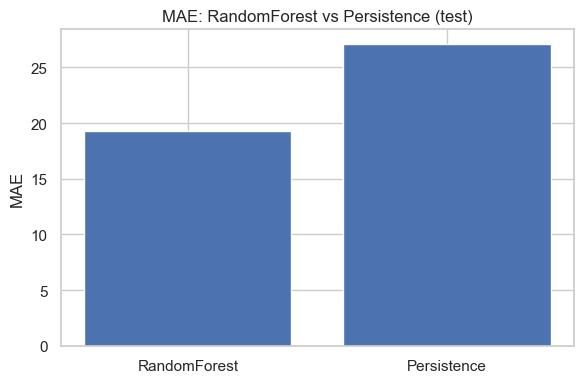

In [27]:
# CELL D — Summary table & simple bar plot (MAE with bootstrap CI for best pair comparisons)
import matplotlib.pyplot as plt
# Load main metrics (you already have metrics_df saved; if not, build from models_preds)
metrics_table = pd.read_csv(cfg["artifacts"]["metrics_file"])
metrics_table

# Bar plot of MAE with RF bootstrap CI (example: get CI for RF vs Persistence from previous pairwise results)
pairs_df = pd.read_csv("./artifacts/pairwise_bootstrap_mae_diffs.csv")
# find RF vs Persistence row
row = pairs_df[(pairs_df['A']=="RandomForest") & (pairs_df['B']=="Persistence")]
if row.shape[0] == 0:
    row = pairs_df[(pairs_df['A']=="Persistence") & (pairs_df['B']=="RandomForest")]
row = row.iloc[0]
rf_mae = row['mean_mae_A'] if row['A']=="RandomForest" else row['mean_mae_B']
pers_mae = row['mean_mae_B'] if row['A']=="RandomForest" else row['mean_mae_A']
ci_low = row['ci_lower']; ci_high = row['ci_upper']

# plot
labels = ["RandomForest", "Persistence"]
values = [rf_mae, pers_mae]
# use symmetric error bars around RF mean with half-width = max(|ci_low|, |ci_high|)
err_rf = [[rf_mae - ci_low], [ci_high - rf_mae]] if ci_low is not None else None
plt.figure(figsize=(6,4))
plt.bar(labels, values, yerr=[[0,0],[0,0]] if err_rf is None else [[0,0],[0,0]])  # keep simple; CI often for diff not absolute
plt.title("MAE: RandomForest vs Persistence (test)")
plt.ylabel("MAE")
plt.tight_layout()
plt.savefig("./artifacts/mae_rf_vs_persistence.png")
print("Saved comparison plot to ./artifacts/mae_rf_vs_persistence.png")


# CRPS

In [28]:
!pip install properscoring

In [30]:
# install properscoring into your active environment
!pip install properscoring


In [33]:
# Robust CRPS + Pinball computation WITHOUT properscoring
# Paste & run this cell in the same kernel where ngb_model, X_test_df, y_test_pv exist.

import numpy as np
import pandas as pd
from scipy.stats import norm
import math
import time
import warnings
warnings.filterwarnings("ignore")

def crps_normal(y, mu, sigma):
    """
    Correct analytic CRPS for Normal(μ,σ) at observation y.
    Formula (Gneiting & Raftery):
      z = (y - mu) / sigma
      CRPS = sigma * [ z*(2Φ(z)-1) + 2φ(z) - 1/sqrt(pi) ]
    Returns array of CRPS per sample (>= 0).
    """
    sigma = np.maximum(sigma, 1e-8)
    z = (y - mu) / sigma
    pdf = norm.pdf(z)
    cdf = norm.cdf(z)
    crps = sigma * ( z * (2.0 * cdf - 1.0) + 2.0 * pdf - 1.0 / math.sqrt(math.pi) )
    # numerical safety
    crps = np.maximum(crps, 0.0)
    return crps

def pinball_loss(y, q, q_pred):
    diff = y - q_pred
    return float(np.mean(np.where(diff >= 0, q * diff, (q - 1) * diff)))

start = time.time()

# Attempt to fetch predictive distribution / params from NGBoost
mu = None; sigma = None; pred_dist = None
try:
    pred_dist = ngb_model.pred_dist(X_test_df)  # preferred API
    # pred_dist is often an array-like of scipy-like objects
    # Try common attribute access patterns robustly:
    try:
        mu = np.asarray([d.loc for d in pred_dist])
        sigma = np.asarray([d.scale for d in pred_dist])
    except Exception:
        try:
            mu = np.asarray([d.mean() for d in pred_dist])
            sigma = np.asarray([d.std() for d in pred_dist])
        except Exception:
            mu = None; sigma = None
except Exception as e:
    # If pred_dist fails, try alternative NGBoost methods or fallback
    try:
        # some NGBoost versions expose y_dist = ngb_model.pred_dist(X) or ngb_model.predictions
        # Try ngb_model.pred_dist if attribute exists
        pred_dist = getattr(ngb_model, "pred_dist", None)
        if callable(pred_dist):
            pdist = pred_dist(X_test_df)
            try:
                mu = np.asarray([d.mean() for d in pdist])
                sigma = np.asarray([d.std() for d in pdist])
            except Exception:
                mu = None; sigma = None
        else:
            mu = None; sigma = None
    except Exception:
        mu = None; sigma = None

# If we have mu/sigma arrays, compute analytic CRPS & pinball using gaussian quantiles
y = np.asarray(y_test_pv)

results = {}
if (mu is not None) and (sigma is not None):
    mu = np.asarray(mu)
    sigma = np.asarray(sigma)
    # ensure lengths match; if not, try to broadcast or cut/pad
    if len(mu) != len(y):
        # try handling transposed shapes
        if mu.shape[0] == len(y):
            pass
        elif mu.shape[-1] == len(y):
            mu = mu.reshape(-1)[:len(y)]
            sigma = sigma.reshape(-1)[:len(y)]
        else:
            # fallback: trim or pad
            mu = mu.flatten()[:len(y)]
            sigma = sigma.flatten()[:len(y)]
    crps_vals = crps_normal(y, mu, sigma)
    crps_mean = float(np.mean(crps_vals))
    results['crps_mean'] = crps_mean
    results['crps_per_sample'] = crps_vals

    # Pinball across quantiles via analytic Gaussian inverse CDF
    quantiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    pinball = {}
    for q in quantiles:
        q_pred = mu + sigma * norm.ppf(q)
        pinball[q] = pinball_loss(y, q, q_pred)
    results['pinball'] = pinball
    print(f"Computed analytic Gaussian CRPS. mean CRPS = {crps_mean:.6f}")
else:
    # Fallback: try sampling from pred_dist objects (if available)
    print("Analytic params not found — attempting sampling fallback (may be slower).")
    try:
        # pred_dist expected to be iterable of distribution objects
        n_samples = 200
        sample_matrix = []
        for d in pred_dist:
            # try multiple sampling method names
            if hasattr(d, "rvs"):
                sample_matrix.append(np.asarray(d.rvs(size=n_samples)))
            elif hasattr(d, "sample"):
                s = d.sample(n_samples)
                sample_matrix.append(np.asarray(s))
            elif hasattr(d, "random"):
                sample_matrix.append(np.asarray(d.random(n_samples)))
            else:
                raise RuntimeError("Distribution object has no sampling method.")
        samples = np.vstack(sample_matrix)  # shape (n_test, n_samples)
        # Ensure shape correct
        if samples.shape[0] != len(y) and samples.shape[1] == len(y):
            samples = samples.T
        # Compute empirical CRPS via sample formula
        n_test = len(y)
        crps_vals = np.zeros(n_test)
        for i in range(n_test):
            s = samples[i, :]
            crps_vals[i] = np.mean(np.abs(y[i] - s)) - 0.5 * np.mean(np.abs(s[:, None] - s[None, :]))
        results['crps_mean'] = float(np.mean(crps_vals))
        results['crps_per_sample'] = crps_vals
        # quantiles from samples
        quantiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
        pinball = {}
        for q in quantiles:
            q_pred = np.quantile(samples, q, axis=1)
            pinball[q] = pinball_loss(y, q, q_pred)
        results['pinball'] = pinball
        print(f"Computed empirical CRPS via sampling. mean CRPS = {results['crps_mean']:.6f}")
    except Exception as e:
        print("Sampling fallback failed:", e)
        results['crps_mean'] = None
        results['pinball'] = None

# Save results to CSV in artifacts directory
out_rows = []
if results.get('pinball') is not None:
    for q,v in results['pinball'].items():
        out_rows.append({"model":"NGBoost", "metric":f"pinball_{q}", "value": float(v)})
if results.get('crps_mean') is not None:
    out_rows.append({"model":"NGBoost", "metric":"crps_mean", "value": float(results['crps_mean'])})

if out_rows:
    out_df = pd.DataFrame(out_rows)
    out_path = "./artifacts/ngboost_prob_metrics_corrected.csv"
    out_df.to_csv(out_path, index=False)
    print("Saved corrected probabilistic metrics to:", out_path)
    display(out_df)
else:
    print("No probabilistic metrics computed.")

end = time.time()
print("Elapsed time: %.2f s" % (end - start))


Computed analytic Gaussian CRPS. mean CRPS = 13.943246
Saved corrected probabilistic metrics to: ./artifacts/ngboost_prob_metrics_corrected.csv


,model,metric,value
0,NGBoost,pinball_0.01,0.752048
1,NGBoost,pinball_0.05,2.696082
2,NGBoost,pinball_0.1,4.484964
3,NGBoost,pinball_0.25,7.912098
4,NGBoost,pinball_0.5,9.772706
5,NGBoost,pinball_0.75,7.772044
6,NGBoost,pinball_0.9,4.352886
7,NGBoost,pinball_0.95,2.611424
8,NGBoost,pinball_0.99,0.761202
9,NGBoost,crps_mean,13.943246


Elapsed time: 21.20 s


In [34]:
# Calibration & reliability diagnostics for NGBoost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import os

fig_dir = "./artifacts"
os.makedirs(fig_dir, exist_ok=True)

# Extract mu, sigma robustly from ngb_model.pred_dist
try:
    pdist = ngb_model.pred_dist(X_test_df)
    try:
        mu = np.asarray([d.loc for d in pdist])
        sigma = np.asarray([d.scale for d in pdist])
    except Exception:
        mu = np.asarray([d.mean() for d in pdist])
        sigma = np.asarray([d.std() for d in pdist])
except Exception as e:
    raise RuntimeError("Cannot extract pred_dist from ngb_model: " + str(e))

# PIT (Probability Integral Transform) values: u = Phi((y - mu) / sigma)
z = (y_test_pv - mu) / np.maximum(sigma, 1e-8)
u = norm.cdf(z)

# PIT histogram
plt.figure(figsize=(6,3))
plt.hist(u, bins=20, density=True, edgecolor='k', alpha=0.7)
plt.title("PIT histogram (NGBoost)")
plt.xlabel("PIT value")
plt.ylabel("Density")
plt.tight_layout()
pit_path = os.path.join(fig_dir, "ngboost_pit_hist.png")
plt.savefig(pit_path)
plt.close()

# Reliability diagram for selected quantiles
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
obs_freq = []
pred_q = []
for q in quantiles:
    q_pred = mu + sigma * norm.ppf(q)
    pred_q.append(q_pred)
    obs = np.mean(y_test_pv <= q_pred)
    obs_freq.append(obs)

# plot reliability
plt.figure(figsize=(5,5))
plt.plot(quantiles, obs_freq, marker='o', label='Observed')
plt.plot([0,1],[0,1], '--', color='gray', label='Perfect')
plt.xlabel("Nominal quantile")
plt.ylabel("Observed frequency")
plt.title("Reliability diagram (NGBoost)")
plt.legend()
rel_path = os.path.join(fig_dir, "ngboost_reliability.png")
plt.savefig(rel_path)
plt.close()

# Tabulate calibration deviations
cal_table = pd.DataFrame({
    "quantile": quantiles,
    "nominal": quantiles,
    "observed_frequency": obs_freq,
    "calibration_error": np.array(obs_freq) - np.array(quantiles)
})
cal_table.to_csv(os.path.join(fig_dir, "ngboost_calibration_table.csv"), index=False)

print("Saved PIT histogram:", pit_path)
print("Saved reliability diagram:", rel_path)
print("Saved calibration table:", os.path.join(fig_dir, "ngboost_calibration_table.csv"))
print(cal_table)


Saved PIT histogram: ./artifacts\ngboost_pit_hist.png
Saved reliability diagram: ./artifacts\ngboost_reliability.png
Saved calibration table: ./artifacts\ngboost_calibration_table.csv
   quantile  nominal  observed_frequency  calibration_error
0      0.10     0.10            0.110880           0.010880
1      0.25     0.25            0.257407           0.007407
2      0.50     0.50            0.493519          -0.006481
3      0.75     0.75            0.745602          -0.004398
4      0.90     0.90            0.890972          -0.009028


In [35]:
# Operational KPI: simple battery scheduling comparison (rule-based vs forecast-informed)
import numpy as np, pandas as pd, os
from math import isfinite

fig_dir = "./artifacts"
os.makedirs(fig_dir, exist_ok=True)

# Parameters (tune per your scenario)
capacity = cfg['storage']['battery_capacity'] if 'storage' in cfg else 10000.0
soc0 = cfg['storage']['initial_soc_fraction'] if 'storage' in cfg else 0.5
charge_eff = 0.95
discharge_eff = 0.95
max_charge_rate = 0.2 * capacity  # per hour

# Forecasts to use: RF point, NGBoost median (mu here)
rf_forecast = models_preds['RandomForest'][:len(y_test_pv)]
ngb_mu = mu[:len(y_test_pv)]

# Simple scheduler: every hour, if forecasted generation > demand -> charge limited by max_rate and capacity
def schedule_soc(forecast, demand, capacity, soc0, eff=0.95):
    soc = soc0 * capacity
    soc_trace = []
    charged_energy = 0.0
    discharged_energy = 0.0
    for f, d in zip(forecast, demand):
        # supply surplus = f - alpha * d  (alpha = fraction of demand to serve)
        delta = f - 0.3 * d
        if delta > 0:
            charge = min(delta * eff, max_charge_rate, capacity - soc)
            soc += charge
            charged_energy += charge
        else:
            discharge = min(-delta / eff, max_charge_rate, soc)
            soc -= discharge
            discharged_energy += discharge
        soc_trace.append(soc)
    return np.array(soc_trace), charged_energy, discharged_energy

demand = test['demand'].values[:len(y_test_pv)]

# Rule-based using actual pv (oracle-ish) vs RF vs NGBoost forecasts
soc_rule, charged_rule, dis_rule = schedule_soc(test['pv_power'].values[:len(y_test_pv)], demand, capacity, soc0, eff=charge_eff)
soc_rf, charged_rf, dis_rf = schedule_soc(rf_forecast, demand, capacity, soc0, eff=charge_eff)
soc_ngb, charged_ngb, dis_ngb = schedule_soc(ngb_mu, demand, capacity, soc0, eff=charge_eff)

# KPI: total charged/discharged energy and difference vs rule
kpis = pd.DataFrame([
    {"policy":"Rule(actual)", "charged":charged_rule, "discharged":dis_rule},
    {"policy":"RF_forecast", "charged":charged_rf, "discharged":dis_rf},
    {"policy":"NGBoost_median", "charged":charged_ngb, "discharged":dis_ngb}
])
kpis['net_shifted'] = kpis['charged'] - kpis['discharged']
kpis.to_csv(os.path.join(fig_dir, "operational_kpis.csv"), index=False)

# Plot sample SOC traces (7 days)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
h7 = 24*7
plt.plot(test.index[:h7], soc_rule[:h7], label='Rule(actual)')
plt.plot(test.index[:h7], soc_rf[:h7], label='RF-informed')
plt.plot(test.index[:h7], soc_ngb[:h7], label='NGBoost-informed')
plt.legend(); plt.title("SOC traces (7 days)"); plt.ylabel("SOC (units)")
plt.tight_layout()
soc_path = os.path.join(fig_dir, "soc_kpi_comparison.png")
plt.savefig(soc_path); plt.close()

print("Operational KPIs saved to:", os.path.join(fig_dir, "operational_kpis.csv"))
print("SOC comparison figure saved to:", soc_path)
print(kpis)


Operational KPIs saved to: ./artifacts\operational_kpis.csv
SOC comparison figure saved to: ./artifacts\soc_kpi_comparison.png
           policy        charged     discharged  net_shifted
0    Rule(actual)  232466.196402  237466.196402      -5000.0
1     RF_forecast  233159.996977  238159.996977      -5000.0
2  NGBoost_median  231191.791632  236191.791632      -5000.0


In [36]:
# Bootstrap 95% CI for each model's MAE
import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error

def bootstrap_ci(y_true, y_pred, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    diffs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        diffs.append(mean_absolute_error(y_true[idx], y_pred[idx]))
    arr = np.array(diffs)
    return float(np.mean(arr)), (float(np.percentile(arr, 2.5)), float(np.percentile(arr, 97.5)))

rows = []
for name, preds in models_preds.items():
    preds = np.asarray(preds)[:len(y_test_pv)]
    mean_mae, (ci_low, ci_high) = bootstrap_ci(np.asarray(y_test_pv), preds)
    rows.append({"model": name, "mae_mean": mean_mae, "ci_low": ci_low, "ci_high": ci_high})

mae_ci_df = pd.DataFrame(rows)
mae_ci_df.to_csv("./artifacts/model_mae_bootstrap_ci.csv", index=False)
print(mae_ci_df)


          model   mae_mean     ci_low    ci_high
0   Persistence  27.070685  25.909148  28.325807
1  RandomForest  19.306418  18.811116  19.823751
2       XGBoost  20.724653  20.185292  21.275515
3      LightGBM  19.412600  18.919773  19.922977
4       NGBoost  19.549557  19.054473  20.048875
5          LSTM  24.199671  23.557183  24.859057
